## Cleaning

In [22]:
import pandas as pd

In [23]:
label1_df = pd.read_csv('labeling1.csv')
label2_df = pd.read_csv('labeling2.csv')
label3_df = pd.read_csv('labeling3.csv')
label4_df = pd.read_csv('labeling4.csv')

I will define a function to clean and merge the 'topic' and 'topic_other' columns. This function will remove the 'TOPIC: ' prefix from the 'topic' column and then combine the two columns, prioritizing the 'topic' column if both are present.

In [24]:
def clean_and_merge_topic_columns(df):
    # Ensure 'topic' and 'topic_other' columns exist, fill with None if not
    if 'topic' not in df.columns:
        df['topic'] = None
    if 'topic_other' not in df.columns:
        df['topic_other'] = None

    # Convert to string and clean 'topic' column (remove any 'topic: ' prefix, case-insensitive)
    df['topic'] = df['topic'].astype(str).str.lower().str.replace(r'topic: ?', '', regex=True).str.strip()

    # Convert to string and clean 'topic_other' column (remove any 'topic: ' prefix, case-insensitive)
    df['topic_other'] = df['topic_other'].astype(str).str.lower().str.replace(r'topic: ?', '', regex=True).str.strip()

    # Merge 'topic' and 'topic_other' into 'topic' column, prioritizing existing 'topic' values
    df['topic'] = df['topic'].replace('nan', pd.NA).fillna(df['topic_other'].replace('nan', pd.NA))

    # Drop the original 'topic_other' column if it existed
    if 'topic_other' in df.columns:
        df = df.drop(columns=['topic_other'])

    # Convert all topic entries to title case for consistency, handle specific cases
    df['topic'] = df['topic'].astype(str).apply(lambda x: x.title() if pd.notna(x) else pd.NA)
    df['topic'] = df['topic'].replace({'Personal Story': 'Personal Story'})

    # Replace 'Nan' (from title case) with pd.NA
    df['topic'] = df['topic'].replace('Nan', pd.NA)

    return df

Now I will apply this function to all four DataFrames and display the `info()` for each to verify the changes.

In [25]:
# Apply the cleaning function to each DataFrame
label1_df = clean_and_merge_topic_columns(label1_df)
label2_df = clean_and_merge_topic_columns(label2_df)
label3_df = clean_and_merge_topic_columns(label3_df)
label4_df = clean_and_merge_topic_columns(label4_df)

# Define the topic re-mapping dictionary for reducing categories
topic_remapping = {
    'News': 'News',
    'Technology': 'Technology',
    'Other': 'Other',
    'Entertainment': 'Entertainment',
    'Education': 'Education & Academic',
    'Sports': 'Sports',
    'Travel': 'Travel & Transport',
    'Science': 'Science & Health',
    'Health': 'Science & Health',
    'Business': 'Business & Finance',
    'Law': 'Law',
    'Personal Story': 'Personal & Beliefs',
    'Black Magic': 'Religion & Spirituality',
    'Art': 'Arts & Lifestyle',
    'Religion': 'Religion & Spirituality',
    'Music': 'Arts & Lifestyle',
    'Food': 'Arts & Lifestyle',
    'History': 'Education & Academic',
    'Finance': 'Business & Finance',
    'Photography': 'Arts & Lifestyle',
    'Aviation': 'Travel & Transport',
    'Shopping': 'Arts & Lifestyle',
    'Creative Writing': 'Arts & Lifestyle',
    'Philosophy': 'Education & Academic',
    'Birthday Celebration': 'Arts & Lifestyle',
    'Lifestyle': 'Arts & Lifestyle',
    'Bikes': 'Travel & Transport',
    'Books': 'Books',
    'Crime': 'News',
    'Electoral': 'News',
    'Art & Craft': 'Arts & Lifestyle',
    'Land': 'Other',
    'Law, Justice': 'Education & Academic',
    'Product Specs': 'Technology',
    'Machinery': 'Technology',
    'Environment': 'Science & Health',
    'Transport': 'Travel & Transport',
    'Home Decor': 'Arts & Lifestyle',
    pd.NA: 'Other' # Ensure NaN values are also mapped to 'Other'
}

# Apply the re-mapping to the 'topic' column of each DataFrame
label1_df['topic'] = label1_df['topic'].map(topic_remapping)
label2_df['topic'] = label2_df['topic'].map(topic_remapping)
label3_df['topic'] = label3_df['topic'].map(topic_remapping)
label4_df['topic'] = label4_df['topic'].map(topic_remapping)

print("\n--- label1_df topic value counts after cleaning and remapping ---")
display(label1_df['topic'].value_counts(dropna=False))

print("\n--- label2_df topic value counts after cleaning and remapping ---")
display(label2_df['topic'].value_counts(dropna=False))

print("\n--- label3_df topic value counts after cleaning and remapping ---")
display(label3_df['topic'].value_counts(dropna=False))

print("\n--- label4_df topic value counts after cleaning and remapping ---")
display(label4_df['topic'].value_counts(dropna=False))


--- label1_df topic value counts after cleaning and remapping ---


,count
topic,
News,18
Technology,12
Other,8
Arts & Lifestyle,8
Education & Academic,7
Entertainment,7
Science & Health,6
Travel & Transport,4
Sports,4



--- label2_df topic value counts after cleaning and remapping ---


,count
topic,
Technology,10
Sports,5
Business & Finance,4
Education & Academic,4
Other,2
Arts & Lifestyle,2
Law,1
NaN,1
Science & Health,1



--- label3_df topic value counts after cleaning and remapping ---


,count
topic,
Travel & Transport,1
Business & Finance,1
Other,1
News,1



--- label4_df topic value counts after cleaning and remapping ---


,count
topic,
Entertainment,2
News,2
Travel & Transport,1
Books,1


Here are the first few rows of `label1_df` to show the updated 'topic' column:

In [26]:
def clean_readability_columns(df):
    # Ensure 'readability' column exists, fill with None if not
    if 'readability' not in df.columns:
        df['readability'] = None

    # Convert to string and clean 'readability' column (remove any 'readability: ' prefix, case-insensitive)
    df['readability'] = df['readability'].astype(str).str.lower().str.replace(r'readability: ?', '', regex=True).str.strip()

    # Handle 'nan' strings from string conversion
    df['readability'] = df['readability'].replace('nan', pd.NA)

    # Convert all readability entries to title case for consistency
    df['readability'] = df['readability'].astype(str).apply(lambda x: x.title() if pd.notna(x) else pd.NA)

    # Replace 'Nan' (from title case) with pd.NA
    df['readability'] = df['readability'].replace('Nan', pd.NA)

    return df

# Apply the cleaning function to each DataFrame
label1_df = clean_readability_columns(label1_df)
label2_df = clean_readability_columns(label2_df)
label3_df = clean_readability_columns(label3_df)
label4_df = clean_readability_columns(label4_df)

print("\n--- label1_df readability value counts after cleaning ---")
display(label1_df['readability'].value_counts(dropna=False))

print("\n--- label2_df readability value counts after cleaning ---")
display(label2_df['readability'].value_counts(dropna=False))

print("\n--- label3_df readability value counts after cleaning ---")
display(label3_df['readability'].value_counts(dropna=False))

print("\n--- label4_df readability value counts after cleaning ---")
display(label4_df['readability'].value_counts(dropna=False))


--- label1_df readability value counts after cleaning ---


,count
readability,
Easy,67
<Na>,11
Medium,6
Technical,3



--- label2_df readability value counts after cleaning ---


,count
readability,
Easy,14
Technical,12
Medium,5



--- label3_df readability value counts after cleaning ---


,count
readability,
Easy,3
<Na>,1



--- label4_df readability value counts after cleaning ---


,count
readability,
Easy,6


In [27]:
def clean_and_merge_cleaning_columns(df):
    # Ensure 'cleaning_quality' and 'cleaning_other' columns exist, fill with None if not
    if 'cleaning_quality' not in df.columns:
        df['cleaning_quality'] = None
    if 'cleaning_other' not in df.columns:
        df['cleaning_other'] = None

    # Convert to string and clean 'cleaning_quality' column (remove any 'cleaning: ' prefix, case-insensitive)
    df['cleaning_quality'] = df['cleaning_quality'].astype(str).str.lower().str.replace(r'cleaning: ?', '', regex=True).str.strip()

    # Convert to string and clean 'cleaning_other' column (remove any 'cleaning: ' prefix, case-insensitive)
    df['cleaning_other'] = df['cleaning_other'].astype(str).str.lower().str.replace(r'cleaning: ?', '', regex=True).str.strip()

    # Merge 'cleaning_quality' and 'cleaning_other' into 'cleaning_quality' column
    # Prioritize 'cleaning_other' if 'cleaning_quality' is 'other' or NaN
    # Handle 'nan' strings from string conversion before fillna
    df['cleaning_quality'] = df['cleaning_quality'].replace('nan', pd.NA)
    df['cleaning_other'] = df['cleaning_other'].replace('nan', pd.NA)

    # Fill 'cleaning_quality' with 'cleaning_other' where 'cleaning_quality' is 'other' or null
    mask_for_other = (df['cleaning_quality'].isna()) | (df['cleaning_quality'] == 'other')
    df.loc[mask_for_other, 'cleaning_quality'] = df.loc[mask_for_other, 'cleaning_other'].fillna(df.loc[mask_for_other, 'cleaning_quality'])

    # Drop the original 'cleaning_other' column if it existed
    if 'cleaning_other' in df.columns:
        df = df.drop(columns=['cleaning_other'])

    # Convert all cleaning quality entries to title case for consistency
    df['cleaning_quality'] = df['cleaning_quality'].astype(str).apply(lambda x: x.title() if pd.notna(x) else pd.NA)

    # Replace 'Nan' (from title case) with pd.NA
    df['cleaning_quality'] = df['cleaning_quality'].replace('Nan', pd.NA)

    return df

# Apply the cleaning function to each DataFrame
label1_df = clean_and_merge_cleaning_columns(label1_df)
label2_df = clean_and_merge_cleaning_columns(label2_df)
label3_df = clean_and_merge_cleaning_columns(label3_df)
label4_df = clean_and_merge_cleaning_columns(label4_df)

print("\n--- label1_df cleaning_quality value counts after cleaning ---")
display(label1_df['cleaning_quality'].value_counts(dropna=False))

print("\n--- label2_df cleaning_quality value counts after cleaning ---")
display(label2_df['cleaning_quality'].value_counts(dropna=False))

print("\n--- label3_df cleaning_quality value counts after cleaning ---")
display(label3_df['cleaning_quality'].value_counts(dropna=False))

print("\n--- label4_df cleaning_quality value counts after cleaning ---")
display(label4_df['cleaning_quality'].value_counts(dropna=False))


--- label1_df cleaning_quality value counts after cleaning ---


,count
cleaning_quality,
Clean,41
Missing Content,38
<Na>,6
Unrequired Content Included,1
No Formatting,1



--- label2_df cleaning_quality value counts after cleaning ---


,count
cleaning_quality,
Clean,23
Missing Content,3
<Na>,2
Malformed Text,2
Formatting Problems,1



--- label3_df cleaning_quality value counts after cleaning ---


,count
cleaning_quality,
Clean,4



--- label4_df cleaning_quality value counts after cleaning ---


,count
cleaning_quality,
Clean,6


In [28]:
label1_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87 entries, 0 to 86
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   annotation_id        87 non-null     int64  
 1   annotator            87 non-null     int64  
 2   c4_id                0 non-null      float64
 3   cleaning_quality     87 non-null     object 
 4   comments             59 non-null     object 
 5   content_moderation   2 non-null      object 
 6   created_at           87 non-null     object 
 7   document_type        73 non-null     object 
 8   document_type_other  7 non-null      object 
 9   id                   87 non-null     object 
 10  lead_time            87 non-null     float64
 11  media                34 non-null     object 
 12  metadata             87 non-null     object 
 13  pii_labels           17 non-null     object 
 14  privacy_type         69 non-null     object 
 15  quality_score        85 non-null     objec

In [29]:
import json
import pandas as pd
import re

def _process_privacy_entry(entry):
    if pd.isna(entry) or str(entry).strip().lower() in ['nan', 'none']:
        return pd.NA

    labels_set = set()
    text_entry = str(entry).strip()

    # Attempt to parse as JSON first
    try:
        data = json.loads(text_entry)
        extracted_list = []
        if isinstance(data, dict):
            if 'choices' in data and isinstance(data['choices'], list):
                extracted_list.extend(data['choices'])
            if 'labels' in data and isinstance(data['labels'], list):
                extracted_list.extend(data['labels'])
        elif isinstance(data, list):
            for item in data:
                if isinstance(item, dict) and 'labels' in item and isinstance(item['labels'], list):
                    extracted_list.extend(item['labels'])

        for label in extracted_list:
            if isinstance(label, str) and label.strip():
                labels_set.add(label.strip())
    except json.JSONDecodeError:
        # Not a JSON string, process as comma-separated values
        cleaned_text = re.sub(r'[[\\]{}|"]', '', text_entry)
        for label in cleaned_text.split(','):
            if label.strip():
                labels_set.add(label.strip())

    final_formatted_labels = []
    for label in labels_set:
        # Remove 'PRIVACY: ' prefix (with space) if present (case-insensitive)
        if label.lower().startswith('privacy: '):
            content = label[len('privacy: '):].strip()
        # If not 'PRIVACY: ', check for 'PRIVACY:' (without space)
        elif label.lower().startswith('privacy:'):
            content = label[len('privacy:'):].strip()
        else:
            content = label.strip()

        # Now, title case the content
        if content:
            final_formatted_labels.append(content.title())

    final_formatted_labels = sorted(list(set([l for l in final_formatted_labels if l and l.lower() != 'none'])))

    if final_formatted_labels:
        return ", ".join(final_formatted_labels)
    else:
        return pd.NA

def clean_privacy_type_column(df):
    # Ensure 'privacy_type' and 'pii_labels' columns exist, fill with pd.NA if not
    if 'privacy_type' not in df.columns:
        df['privacy_type'] = pd.NA
    if 'pii_labels' not in df.columns:
        df['pii_labels'] = pd.NA

    # Process both columns independently first
    processed_privacy_type_series = df['privacy_type'].apply(lambda x: _process_privacy_entry(x))
    processed_pii_labels_series = df['pii_labels'].apply(lambda x: _process_privacy_entry(x))

    # Combine the labels from both processed series into a new set for each row
    combined_final_labels = []
    for pt_val, pii_val in zip(processed_privacy_type_series, processed_pii_labels_series):
        current_labels_set = set()
        if pd.notna(pt_val):
            for label in str(pt_val).split(', '):
                if label.strip():
                    current_labels_set.add(label.strip())
        if pd.notna(pii_val):
            for label in str(pii_val).split(', '):
                if label.strip():
                    current_labels_set.add(label.strip())

        if current_labels_set:
            combined_final_labels.append(", ".join(sorted(list(current_labels_set))))
        else:
            combined_final_labels.append(pd.NA)

    df['privacy_type'] = combined_final_labels

    # Replace 'Nan' (from previous title case or processing) with pd.NA after cleaning and formatting
    df['privacy_type'] = df['privacy_type'].replace('Nan', pd.NA)

    # Do NOT drop the 'pii_labels' column as per current user intent to utilize its data.
    return df

# Apply the cleaning function to each DataFrame
label1_df = clean_privacy_type_column(label1_df)
label2_df = clean_privacy_type_column(label2_df)
label3_df = clean_privacy_type_column(label3_df)
label4_df = clean_privacy_type_column(label4_df)

print("\n--- label1_df privacy_type value counts after cleaning ---")
display(label1_df['privacy_type'].value_counts(dropna=False))

print("\n--- label2_df privacy_type value counts after cleaning ---")
display(label2_df['privacy_type'].value_counts(dropna=False))

print("\n--- label3_df privacy_type value counts after cleaning ---")
display(label3_df['privacy_type'].value_counts(dropna=False))

print("\n--- label4_df privacy_type value counts after cleaning ---")
display(label4_df['privacy_type'].value_counts(dropna=False))


--- label1_df privacy_type value counts after cleaning ---


,count
privacy_type,
<NA>,52
Person Name,25
"Other Pii, Person Name",3
"Address, Person Name",2
"Medical Information, Person Name",2
"Address, Medical Information, Person Name, Phone Number",1
"Email, Other Pii",1
Username,1



--- label2_df privacy_type value counts after cleaning ---


,count
privacy_type,
<NA>,18
Person Name,10
"Medical Information, Person Name",1
"Address, Person Name",1
"Financial Information, Person Name",1



--- label3_df privacy_type value counts after cleaning ---


,count
privacy_type,
<NA>,2
Person Name,1
"Address, Person Name",1



--- label4_df privacy_type value counts after cleaning ---


,count
privacy_type,
<NA>,5
Person Name,1


In [30]:
def clean_and_merge_document_type_columns(df):
    # Ensure 'document_type' and 'document_type_other' columns exist, fill with pd.NA if not
    if 'document_type' not in df.columns:
        df['document_type'] = pd.NA
    if 'document_type_other' not in df.columns:
        df['document_type_other'] = pd.NA

    # Convert to string and clean 'document_type' column (remove any 'DOC_TYPE: ' prefix, case-insensitive)
    df['document_type'] = df['document_type'].astype(str).str.lower().str.replace(r'doc_type: ?', '', regex=True).str.strip()

    # Convert to string and clean 'document_type_other' column (remove any 'DOC_TYPE: ' prefix, case-insensitive)
    df['document_type_other'] = df['document_type_other'].astype(str).str.lower().str.replace(r'doc_type: ?', '', regex=True).str.strip()

    # Handle 'nan' strings from string conversion before fillna
    df['document_type'] = df['document_type'].replace('nan', pd.NA)
    df['document_type_other'] = df['document_type_other'].replace('nan', pd.NA)

    # Merge 'document_type_other' into 'document_type', prioritizing existing 'document_type' values
    df['document_type'] = df['document_type'].fillna(df['document_type_other'])

    # Drop the original 'document_type_other' column if it existed
    if 'document_type_other' in df.columns:
        df = df.drop(columns=['document_type_other'])

    # Convert all document_type entries to title case for consistency
    df['document_type'] = df['document_type'].astype(str).apply(lambda x: x.title() if pd.notna(x) else pd.NA)

    # Replace 'Nan' (from title case) with pd.NA
    df['document_type'] = df['document_type'].replace('Nan', pd.NA)

    return df

# Apply the cleaning function to each DataFrame
label1_df = clean_and_merge_document_type_columns(label1_df)
label2_df = clean_and_merge_document_type_columns(label2_df)
label3_df = clean_and_merge_document_type_columns(label3_df)
label4_df = clean_and_merge_document_type_columns(label4_df)

print("\n--- label1_df document_type value counts after cleaning and merging ---")
display(label1_df['document_type'].value_counts(dropna=False))

print("\n--- label2_df document_type value counts after cleaning and merging ---")
display(label2_df['document_type'].value_counts(dropna=False))

print("\n--- label3_df document_type value counts after cleaning and merging ---")
display(label3_df['document_type'].value_counts(dropna=False))

print("\n--- label4_df document_type value counts after cleaning and merging ---")
display(label4_df['document_type'].value_counts(dropna=False))


--- label1_df document_type value counts after cleaning and merging ---


,count
document_type,
Blog,36
Article,14
Forum Post,10
<Na>,8
Product Page,6
Other,4
Academic,2
Government,1
Recipe Website,1



--- label2_df document_type value counts after cleaning and merging ---


,count
document_type,
Records,12
Product Catalogue,3
Documentation,2
Government,2
Academic,2
Patent,2
Meeting Agenda,2
Email Copy,1
Article,1



--- label3_df document_type value counts after cleaning and merging ---


,count
document_type,
Blog,3
<Na>,1



--- label4_df document_type value counts after cleaning and merging ---


,count
document_type,
Blog,4
Article,2


In [31]:
def _extract_quality_score(entry):
    if pd.isna(entry):
        return 0
    try:
        # The entry is a string representation of a list of dictionaries
        # Example: '[{"rating":10}]'
        data = json.loads(str(entry))
        if isinstance(data, list) and data:
            for item in data:
                if isinstance(item, dict) and 'rating' in item:
                    return item['rating']
        return 0 # Return 0 if 'rating' key is not found in any dict within the list
    except (json.JSONDecodeError, TypeError):
        # Handle cases where it's not a valid JSON string or other parsing issues
        return 0

def clean_quality_score_column(df):
    # Ensure 'quality_score' column exists, fill with pd.NA if not
    if 'quality_score' not in df.columns:
        df['quality_score'] = pd.NA

    # Apply the extraction function to the 'quality_score' column
    df['quality_score'] = df['quality_score'].apply(_extract_quality_score)

    # Ensure the column is numeric and fill any remaining non-numeric (e.g., from original NaNs) with 0
    df['quality_score'] = pd.to_numeric(df['quality_score'], errors='coerce').fillna(0).astype(int)

    return df

# Apply the cleaning function to each DataFrame
label1_df = clean_quality_score_column(label1_df)
label2_df = clean_quality_score_column(label2_df)
label3_df = clean_quality_score_column(label3_df)
label4_df = clean_quality_score_column(label4_df)

print("\n--- label1_df quality_score value counts after cleaning ---")
display(label1_df['quality_score'].value_counts(dropna=False))

print("\n--- label2_df quality_score value counts after cleaning ---")
display(label2_df['quality_score'].value_counts(dropna=False))

print("\n--- label3_df quality_score value counts after cleaning ---")
display(label3_df['quality_score'].value_counts(dropna=False))

print("\n--- label4_df quality_score value counts after cleaning ---")
display(label4_df['quality_score'].value_counts(dropna=False))


--- label1_df quality_score value counts after cleaning ---


,count
quality_score,
10,38
9,15
7,10
6,7
8,5
5,5
4,3
0,2
1,1



--- label2_df quality_score value counts after cleaning ---


,count
quality_score,
10,21
7,3
8,3
5,1
2,1
9,1
1,1



--- label3_df quality_score value counts after cleaning ---


,count
quality_score,
10,4



--- label4_df quality_score value counts after cleaning ---


,count
quality_score,
10,6


In [32]:
label2_df['metadata'].iloc[0]

'{"url":"https:\\/\\/www.mcslions.org\\/wp-content\\/uploads\\/2014\\/11\\/Track-Records-2015.pdf","id":"<urn:uuid:428e3e98-c3af-40aa-aa8c-8b87f65b49a2>","date":"2021-01-28T05:55:26+00:00","language":"eng_Latn"}'

In [33]:
import json
import pandas as pd

def _determine_source(row):
    metadata_str = row['metadata']
    doc_id = row['id']

    meta_dict = {}
    if pd.notna(metadata_str):
        try:
            meta_dict = json.loads(str(metadata_str))
        except json.JSONDecodeError:
            # If metadata is not valid JSON, treat as empty dict for key checks
            pass

    # 1. Redpajama: redpajama_id in metadata
    if 'redpajama_id' in meta_dict:
        return "Redpajama"

    # 2. C4: file_path starting with s3 in metadata
    if 'file_path' in meta_dict and isinstance(meta_dict['file_path'], str) and str(meta_dict['file_path']).startswith('s3:'):
        return "C4"

    is_finepdf_by_language = 'language' in meta_dict and pd.notna(meta_dict['language']) and str(meta_dict['language']).strip() != ''

    if is_finepdf_by_language:
        return "FinePdf"

    # 4. FineWeb: 'timestamp' or 'date' in metadata (and not categorized by previous rules)
    if 'timestamp' in meta_dict or 'date' in meta_dict:
        return "FineWeb"

    return "Unknown"

def create_src_column(df):
    # Apply the helper function to create the 'src' column
    df['src'] = df.apply(_determine_source, axis=1)
    return df

# Apply the function to each DataFrame
label1_df = create_src_column(label1_df)
label2_df = create_src_column(label2_df)
label3_df = create_src_column(label3_df)
label4_df = create_src_column(label4_df)

print("\n--- label1_df src value counts ---")
display(label1_df['src'].value_counts(dropna=False))

print("\n--- label2_df src value counts ---")
display(label2_df['src'].value_counts(dropna=False))

print("\n--- label3_df src value counts ---")
display(label3_df['src'].value_counts(dropna=False))

print("\n--- label4_df src value counts ---")
display(label4_df['src'].value_counts(dropna=False))


--- label1_df src value counts ---


,count
src,
C4,34
FineWeb,31
Redpajama,22



--- label2_df src value counts ---


,count
src,
FinePdf,31



--- label3_df src value counts ---


,count
src,
Redpajama,4



--- label4_df src value counts ---


,count
src,
Redpajama,6


In [34]:
columns_to_keep = [
    'annotation_id',
    'annotator',
    'cleaning_quality',
    'comments',
    'document_type',
    'id',
    'metadata',
    'pii_labels',
    'privacy_type',
    'quality_score',
    'readability',
    'text',
    'timestamp',
    'topic',
    'url',
    'src'
]

def ensure_columns_exist(df, columns):
    for col in columns:
        if col not in df.columns:
            df[col] = pd.NA
    return df

# Ensure all DataFrames have the columns_to_keep, filling with pd.NA if missing
label1_df = ensure_columns_exist(label1_df, columns_to_keep)
label2_df = ensure_columns_exist(label2_df, columns_to_keep)
label3_df = ensure_columns_exist(label3_df, columns_to_keep)
label4_df = ensure_columns_exist(label4_df, columns_to_keep)

# Filter each DataFrame to keep only the specified columns
label1_df_filtered = label1_df[columns_to_keep]
label2_df_filtered = label2_df[columns_to_keep]
label3_df_filtered = label3_df[columns_to_keep]
label4_df_filtered = label4_df[columns_to_keep]

# Concatenate the filtered DataFrames
merged_df = pd.concat([label1_df_filtered, label2_df_filtered, label3_df_filtered, label4_df_filtered], ignore_index=True)

print("\n--- Merged DataFrame Info ---")
merged_df.info()

print("\n--- Merged DataFrame Head ---")
display(merged_df.head())


--- Merged DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128 entries, 0 to 127
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   annotation_id     128 non-null    int64 
 1   annotator         128 non-null    int64 
 2   cleaning_quality  128 non-null    object
 3   comments          76 non-null     object
 4   document_type     128 non-null    object
 5   id                128 non-null    object
 6   metadata          128 non-null    object
 7   pii_labels        22 non-null     object
 8   privacy_type      51 non-null     object
 9   quality_score     128 non-null    int64 
 10  readability       128 non-null    object
 11  text              128 non-null    object
 12  timestamp         31 non-null     object
 13  topic             124 non-null    object
 14  url               128 non-null    object
 15  src               128 non-null    object
dtypes: int64(3), object(13)
memory 

,annotation_id,annotator,cleaning_quality,comments,document_type,id,metadata,pii_labels,privacy_type,quality_score,readability,text,timestamp,topic,url,src
0,13,1,Clean,Short post about a show there is nothing else ...,Blog,481,"{""url"":""https:\/\/karaokegal.livejournal.com\/...",NaN,<NA>,10,Easy,I thought I was going to finish the 3rd season...,2019-04-18 14:16:05,Entertainment,https://karaokegal.livejournal.com/1773485.html,FineWeb
1,16,1,Clean,A post on forum for advice on web domain,Forum Post,484,"{""url"":""https:\/\/community.homestead.com\/hom...",NaN,<NA>,10,Easy,I have existing web site brittlloyd.org. I ope...,2019-04-25 23:02:23,Technology,https://community.homestead.com/homestead/topi...,FineWeb
2,17,1,Clean,Page has changed content thus quality is lower,Product Page,485,"{""url"":""http:\/\/hotel-east-bourne-resort-and-...",NaN,<NA>,4,Easy,Embrace world class facilities at East Bourne ...,2019-04-24 11:03:03,Travel & Transport,http://hotel-east-bourne-resort-and-spa-shimla...,FineWeb
3,18,1,Missing Content,Misses the last two paragraphs of the website,Article,486,"{""url"":""https:\/\/www.archiscene.net\/tower\/f...",NaN,<NA>,7,Easy,UNStudio has joined forces with HPP Architects...,2019-04-18 12:20:23,News,https://www.archiscene.net/tower/four-frankfur...,FineWeb
4,20,1,Missing Content,Scraped text misses out on some points and par...,Product Page,488,"{""url"":""https:\/\/www.xchangetraining.co.uk\/c...",NaN,<NA>,5,Easy,Learn the fundamentals of Flash as we guide yo...,2019-04-21 18:13:54,Education & Academic,https://www.xchangetraining.co.uk/course/adobe...,FineWeb


In [35]:
# Replace empty strings with pd.NA across the entire DataFrame
merged_df.replace('', pd.NA, inplace=True)

print("\n--- Merged DataFrame Info after replacing empty strings with pd.NA ---")
merged_df.info()

print("\n--- Merged DataFrame Head after replacing empty strings with pd.NA ---")
display(merged_df.head())


--- Merged DataFrame Info after replacing empty strings with pd.NA ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128 entries, 0 to 127
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   annotation_id     128 non-null    int64 
 1   annotator         128 non-null    int64 
 2   cleaning_quality  128 non-null    object
 3   comments          76 non-null     object
 4   document_type     128 non-null    object
 5   id                128 non-null    object
 6   metadata          128 non-null    object
 7   pii_labels        22 non-null     object
 8   privacy_type      51 non-null     object
 9   quality_score     128 non-null    int64 
 10  readability       128 non-null    object
 11  text              128 non-null    object
 12  timestamp         31 non-null     object
 13  topic             124 non-null    object
 14  url               128 non-null    object
 15  src               128 non-null    ob

,annotation_id,annotator,cleaning_quality,comments,document_type,id,metadata,pii_labels,privacy_type,quality_score,readability,text,timestamp,topic,url,src
0,13,1,Clean,Short post about a show there is nothing else ...,Blog,481,"{""url"":""https:\/\/karaokegal.livejournal.com\/...",NaN,<NA>,10,Easy,I thought I was going to finish the 3rd season...,2019-04-18 14:16:05,Entertainment,https://karaokegal.livejournal.com/1773485.html,FineWeb
1,16,1,Clean,A post on forum for advice on web domain,Forum Post,484,"{""url"":""https:\/\/community.homestead.com\/hom...",NaN,<NA>,10,Easy,I have existing web site brittlloyd.org. I ope...,2019-04-25 23:02:23,Technology,https://community.homestead.com/homestead/topi...,FineWeb
2,17,1,Clean,Page has changed content thus quality is lower,Product Page,485,"{""url"":""http:\/\/hotel-east-bourne-resort-and-...",NaN,<NA>,4,Easy,Embrace world class facilities at East Bourne ...,2019-04-24 11:03:03,Travel & Transport,http://hotel-east-bourne-resort-and-spa-shimla...,FineWeb
3,18,1,Missing Content,Misses the last two paragraphs of the website,Article,486,"{""url"":""https:\/\/www.archiscene.net\/tower\/f...",NaN,<NA>,7,Easy,UNStudio has joined forces with HPP Architects...,2019-04-18 12:20:23,News,https://www.archiscene.net/tower/four-frankfur...,FineWeb
4,20,1,Missing Content,Scraped text misses out on some points and par...,Product Page,488,"{""url"":""https:\/\/www.xchangetraining.co.uk\/c...",NaN,<NA>,5,Easy,Learn the fundamentals of Flash as we guide yo...,2019-04-21 18:13:54,Education & Academic,https://www.xchangetraining.co.uk/course/adobe...,FineWeb


In [36]:
import uuid

# Generate a unique UUID for each row in the merged_df
# This overwrites any existing values in the 'id' column with new unique UUIDs
merged_df['id'] = [str(uuid.uuid4()) for _ in range(len(merged_df))]

print("\n--- Merged DataFrame Info after assigning unique IDs ---")
merged_df.info()

print("\n--- Merged DataFrame Head after assigning unique IDs ---")
display(merged_df.head())

print("\n--- Merged DataFrame 'id' value counts (top 10 to check uniqueness) ---")
display(merged_df['id'].value_counts().head(10))


--- Merged DataFrame Info after assigning unique IDs ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128 entries, 0 to 127
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   annotation_id     128 non-null    int64 
 1   annotator         128 non-null    int64 
 2   cleaning_quality  128 non-null    object
 3   comments          76 non-null     object
 4   document_type     128 non-null    object
 5   id                128 non-null    object
 6   metadata          128 non-null    object
 7   pii_labels        22 non-null     object
 8   privacy_type      51 non-null     object
 9   quality_score     128 non-null    int64 
 10  readability       128 non-null    object
 11  text              128 non-null    object
 12  timestamp         31 non-null     object
 13  topic             124 non-null    object
 14  url               128 non-null    object
 15  src               128 non-null    object
dtypes: i

,annotation_id,annotator,cleaning_quality,comments,document_type,id,metadata,pii_labels,privacy_type,quality_score,readability,text,timestamp,topic,url,src
0,13,1,Clean,Short post about a show there is nothing else ...,Blog,a78dc9ef-5a79-4eca-b522-068aadc205df,"{""url"":""https:\/\/karaokegal.livejournal.com\/...",NaN,<NA>,10,Easy,I thought I was going to finish the 3rd season...,2019-04-18 14:16:05,Entertainment,https://karaokegal.livejournal.com/1773485.html,FineWeb
1,16,1,Clean,A post on forum for advice on web domain,Forum Post,4f8c8637-0085-4550-babb-24554a788abb,"{""url"":""https:\/\/community.homestead.com\/hom...",NaN,<NA>,10,Easy,I have existing web site brittlloyd.org. I ope...,2019-04-25 23:02:23,Technology,https://community.homestead.com/homestead/topi...,FineWeb
2,17,1,Clean,Page has changed content thus quality is lower,Product Page,fbc8a179-aa44-4e9e-9f66-ac6205cbcc5c,"{""url"":""http:\/\/hotel-east-bourne-resort-and-...",NaN,<NA>,4,Easy,Embrace world class facilities at East Bourne ...,2019-04-24 11:03:03,Travel & Transport,http://hotel-east-bourne-resort-and-spa-shimla...,FineWeb
3,18,1,Missing Content,Misses the last two paragraphs of the website,Article,302b9918-5e3a-48b0-a93f-aa0918188397,"{""url"":""https:\/\/www.archiscene.net\/tower\/f...",NaN,<NA>,7,Easy,UNStudio has joined forces with HPP Architects...,2019-04-18 12:20:23,News,https://www.archiscene.net/tower/four-frankfur...,FineWeb
4,20,1,Missing Content,Scraped text misses out on some points and par...,Product Page,22cf26a1-82a8-4670-8c92-23fe81db794d,"{""url"":""https:\/\/www.xchangetraining.co.uk\/c...",NaN,<NA>,5,Easy,Learn the fundamentals of Flash as we guide yo...,2019-04-21 18:13:54,Education & Academic,https://www.xchangetraining.co.uk/course/adobe...,FineWeb



--- Merged DataFrame 'id' value counts (top 10 to check uniqueness) ---


,count
id,
a78dc9ef-5a79-4eca-b522-068aadc205df,1
4f8c8637-0085-4550-babb-24554a788abb,1
fbc8a179-aa44-4e9e-9f66-ac6205cbcc5c,1
302b9918-5e3a-48b0-a93f-aa0918188397,1
22cf26a1-82a8-4670-8c92-23fe81db794d,1
6f457388-63e3-40df-96f2-2a9cb3835dd8,1
74768f8d-c95b-4da6-8c5c-c40f25b330ab,1
c27effe2-4dfb-4d2a-afc0-59e36fd5f523,1
a489994a-996a-4fee-8884-df7bcb732414,1


In [37]:
import re

def calculate_num_characters(text):
    if pd.isna(text):
        return 0
    return len(str(text))

def calculate_num_sentences(text):
    if pd.isna(text):
        return 0
    # A simple way to count sentences is to split by common sentence-ending punctuation
    sentences = re.split(r'[.!?]+', str(text))
    # Filter out empty strings that might result from multiple punctuation marks or trailing punctuation
    return len([s.strip() for s in sentences if s.strip()])

# Apply the functions to create the new columns
merged_df['num_characters'] = merged_df['text'].apply(calculate_num_characters)
merged_df['num_sentences'] = merged_df['text'].apply(calculate_num_sentences)

print("\n--- Merged DataFrame Info after adding character and sentence counts ---")
merged_df.info()

print("\n--- Merged DataFrame Head after adding character and sentence counts ---")
display(merged_df.head())


--- Merged DataFrame Info after adding character and sentence counts ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128 entries, 0 to 127
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   annotation_id     128 non-null    int64 
 1   annotator         128 non-null    int64 
 2   cleaning_quality  128 non-null    object
 3   comments          76 non-null     object
 4   document_type     128 non-null    object
 5   id                128 non-null    object
 6   metadata          128 non-null    object
 7   pii_labels        22 non-null     object
 8   privacy_type      51 non-null     object
 9   quality_score     128 non-null    int64 
 10  readability       128 non-null    object
 11  text              128 non-null    object
 12  timestamp         31 non-null     object
 13  topic             124 non-null    object
 14  url               128 non-null    object
 15  src               128 non-null    

,annotation_id,annotator,cleaning_quality,comments,document_type,id,metadata,pii_labels,privacy_type,quality_score,readability,text,timestamp,topic,url,src,num_characters,num_sentences
0,13,1,Clean,Short post about a show there is nothing else ...,Blog,a78dc9ef-5a79-4eca-b522-068aadc205df,"{""url"":""https:\/\/karaokegal.livejournal.com\/...",NaN,<NA>,10,Easy,I thought I was going to finish the 3rd season...,2019-04-18 14:16:05,Entertainment,https://karaokegal.livejournal.com/1773485.html,FineWeb,213,3
1,16,1,Clean,A post on forum for advice on web domain,Forum Post,4f8c8637-0085-4550-babb-24554a788abb,"{""url"":""https:\/\/community.homestead.com\/hom...",NaN,<NA>,10,Easy,I have existing web site brittlloyd.org. I ope...,2019-04-25 23:02:23,Technology,https://community.homestead.com/homestead/topi...,FineWeb,398,10
2,17,1,Clean,Page has changed content thus quality is lower,Product Page,fbc8a179-aa44-4e9e-9f66-ac6205cbcc5c,"{""url"":""http:\/\/hotel-east-bourne-resort-and-...",NaN,<NA>,4,Easy,Embrace world class facilities at East Bourne ...,2019-04-24 11:03:03,Travel & Transport,http://hotel-east-bourne-resort-and-spa-shimla...,FineWeb,223,3
3,18,1,Missing Content,Misses the last two paragraphs of the website,Article,302b9918-5e3a-48b0-a93f-aa0918188397,"{""url"":""https:\/\/www.archiscene.net\/tower\/f...",NaN,<NA>,7,Easy,UNStudio has joined forces with HPP Architects...,2019-04-18 12:20:23,News,https://www.archiscene.net/tower/four-frankfur...,FineWeb,2164,14
4,20,1,Missing Content,Scraped text misses out on some points and par...,Product Page,22cf26a1-82a8-4670-8c92-23fe81db794d,"{""url"":""https:\/\/www.xchangetraining.co.uk\/c...",NaN,<NA>,5,Easy,Learn the fundamentals of Flash as we guide yo...,2019-04-21 18:13:54,Education & Academic,https://www.xchangetraining.co.uk/course/adobe...,FineWeb,1737,14


In [38]:
merged_df['id'].value_counts()

,count
id,
a78dc9ef-5a79-4eca-b522-068aadc205df,1
4f8c8637-0085-4550-babb-24554a788abb,1
fbc8a179-aa44-4e9e-9f66-ac6205cbcc5c,1
302b9918-5e3a-48b0-a93f-aa0918188397,1
22cf26a1-82a8-4670-8c92-23fe81db794d,1
...,...
44028d76-8146-4a77-bfea-787615744f99,1
096e9241-a9e5-4a45-beb4-27f13782bbab,1
2e49657f-02fc-4f33-bd7a-91b4994adcbf,1


In [39]:
merged_df.to_csv('labels.csv', index=False)

# PII Comparison

## Comparing OpenAI's Privacy-Filter Model with Manual Annotations

This section will compare the `privacy_type` annotations in our `merged_df` with predictions from OpenAI's privacy-filter model. We will perform the following steps:

1.  **Install necessary libraries:** Install `transformers` (and `torch` if not already present) to use models from Hugging Face.
2.  **Load the model:** Download and load the `openai/privacy-filter` model.
3.  **Define a prediction function:** Create a function to process text using the model and extract privacy labels.
4.  **Apply the model:** Run the prediction function on the `text` column of `merged_df` to generate model predictions.
5.  **Compare predictions:** Develop logic to compare the model's predictions against the `privacy_type` column.
6.  **Identify False Positives and False Negatives:** Catalogue cases where the model flags content not considered private (false positive) and where it misses private content (false negative).
7.  **Display results:** Show examples and summaries of the comparison.

In [40]:
# Install necessary libraries
!pip install transformers torch pandas scikit-learn


In [41]:
from transformers import pipeline
import torch

# Load the privacy-filter model
# This might take some time and download a significant amount of data
print("Loading OpenAI's privacy-filter model...")
# Use 'text-classification' pipeline for privacy filtering
privacy_classifier = pipeline("token-classification", model="openai/privacy-filter", device=0 if torch.cuda.is_available() else -1)
print("Model loaded successfully.")


Loading OpenAI's privacy-filter model...


config.json:   0%|          | 0.00/3.04k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.80G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/140 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/234 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/27.9M [00:00<?, ?B/s]

Model loaded successfully.


In [43]:
import numpy as np
import json

def get_model_predictions(text):
    if pd.isna(text) or not str(text).strip():
        return pd.NA
    text_str = str(text) # Ensure text is always a string
    predictions_batch = None # Initialize to prevent UnboundLocalError
    try:
        # Call the token-classification pipeline with truncation to handle long texts
        # and a max_length to control token count, mitigating CUDA memory issues.
        predictions_batch = privacy_classifier(text_str)

        # If no entities are found, predictions_batch will be an empty list.
        # Return as pd.NA in this case, otherwise return the raw JSON string.
        if not predictions_batch:
            return pd.NA
        else:
            # Convert the list of dictionaries to a JSON string for storage and inspection
            return predictions_batch
    except Exception as e:
        print(f"Error processing text: {text_str[:50]}... Error: {e}. Raw predictions_batch: {predictions_batch}")
        return pd.NA


# Apply the model to the 'text' column of merged_df. This might take some time.
print("Generating model privacy predictions...")
merged_df['model_privacy_predictions'] = merged_df['text'].apply(get_model_predictions)
print("Model predictions generated.")

print("\n--- Merged DataFrame with Model Predictions (Head) ---\n")
display(merged_df[['text', 'privacy_type', 'model_privacy_predictions']].head(10))

Generating model privacy predictions...


[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Error processing text: Ruud Ultra Series™ Two-Stage Air Conditioners equi... Error: CUDA out of memory. Tried to allocate 64.63 GiB. GPU 0 has a total capacity of 14.56 GiB of which 11.54 GiB is free. Including non-PyTorch memory, this process has 3.02 GiB memory in use. Of the allocated memory 2.74 GiB is allocated by PyTorch, and 156.02 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf). Raw predictions_batch: None
Error processing text: High Court of Judicature at Allahabad

List of Fre... Error: CUDA out of memory. Tried to allocate 13.86 GiB. GPU 0 has a total capacity of 14.56 GiB of which 11.58 GiB is free. Including non-PyTorch memory, this process has 2.98 GiB memory in use. Of the allocated memory 2.68 GiB is

,text,privacy_type,model_privacy_predictions
0,I thought I was going to finish the 3rd season...,<NA>,<NA>
1,I have existing web site brittlloyd.org. I ope...,<NA>,"[{'entity': 'B-private_url', 'score': 0.999959..."
2,Embrace world class facilities at East Bourne ...,<NA>,<NA>
3,UNStudio has joined forces with HPP Architects...,<NA>,<NA>
4,Learn the fundamentals of Flash as we guide yo...,<NA>,<NA>
5,What do you do in your free time? Of course so...,Person Name,"[{'entity': 'B-private_person', 'score': 0.999..."
6,Vashikaran Specialist Chandigarh is a black ma...,Person Name,"[{'entity': 'B-private_person', 'score': 0.636..."
7,"This topic contains 1 reply, has 2 voices. Las...",Person Name,"[{'entity': 'B-private_person', 'score': 0.999..."
8,The Champion work “Uncle Ian III (Into the Unk...,"Address, Person Name","[{'entity': 'B-private_person', 'score': 0.851..."
9,2 New England NE 16 1 plays -1 yards 0...,<NA>,<NA>


In [44]:
def extract_predicted_entities(predictions):
    if not isinstance(predictions, list):
        return pd.NA
    entities = set()
    for item in predictions:
        if isinstance(item, dict) and 'entity' in item:
            entity_value = item['entity'].strip()
            if entity_value:
                entities.add(entity_value)

    if entities:
        return ", ".join(sorted(list(entities)))
    else:
        return pd.NA

merged_df['predicted_entities'] = merged_df['model_privacy_predictions'].apply(extract_predicted_entities)

print("\n--- Merged DataFrame with Extracted Predicted Entities (Head) ---\n")
display(merged_df[['text', 'privacy_type', 'model_privacy_predictions', 'predicted_entities']].head(10))


--- Merged DataFrame with Extracted Predicted Entities (Head) ---



,text,privacy_type,model_privacy_predictions,predicted_entities
0,I thought I was going to finish the 3rd season...,<NA>,<NA>,<NA>
1,I have existing web site brittlloyd.org. I ope...,<NA>,"[{'entity': 'B-private_url', 'score': 0.999959...","B-private_url, E-private_url, I-private_url"
2,Embrace world class facilities at East Bourne ...,<NA>,<NA>,<NA>
3,UNStudio has joined forces with HPP Architects...,<NA>,<NA>,<NA>
4,Learn the fundamentals of Flash as we guide yo...,<NA>,<NA>,<NA>
5,What do you do in your free time? Of course so...,Person Name,"[{'entity': 'B-private_person', 'score': 0.999...","B-private_person, E-private_person, I-private_..."
6,Vashikaran Specialist Chandigarh is a black ma...,Person Name,"[{'entity': 'B-private_person', 'score': 0.636...","B-private_person, E-private_person, I-private_..."
7,"This topic contains 1 reply, has 2 voices. Las...",Person Name,"[{'entity': 'B-private_person', 'score': 0.999...","B-private_person, E-private_person, I-private_..."
8,The Champion work “Uncle Ian III (Into the Unk...,"Address, Person Name","[{'entity': 'B-private_person', 'score': 0.851...","B-private_date, B-private_person, E-private_da..."
9,2 New England NE 16 1 plays -1 yards 0...,<NA>,<NA>,<NA>


In [45]:
def get_unique_predicted_entity_types(df, column_name='predicted_entities'):
    unique_entities = set()
    for entry in df[column_name].dropna():
        # Split the comma-separated string into individual entity tags
        tags = [tag.strip() for tag in entry.split(',') if tag.strip()]
        for tag in tags:
            # Remove BIO prefixes (B-, I-, E-)
            cleaned_tag_without_bio = re.sub(r'^(B-|I-|E-)', '', tag, flags=re.IGNORECASE)
            # Remove 'private_' prefix
            final_entity = re.sub(r'^private_?', '', cleaned_tag_without_bio, flags=re.IGNORECASE)
            if final_entity:
                unique_entities.add(final_entity)
    return sorted(list(unique_entities))

# Get and display the unique entity types from the 'predicted_entities' column
all_unique_predicted_entities = get_unique_predicted_entity_types(merged_df, 'predicted_entities')

print("\n--- Unique Predicted Entity Types ---\n")
for entity in all_unique_predicted_entities:
    print(entity)



--- Unique Predicted Entity Types ---

S-private_person
account_number
address
date
email
person
secret
url


In [46]:
import re

def standardize_predicted_entities(predicted_entities_str):
    if pd.isna(predicted_entities_str) or not isinstance(predicted_entities_str, str):
        return pd.NA

    # Define a mapping from normalized model entity parts to desired privacy types.
    # Keys are lowercase, with no spaces or underscores, and no 'private_' prefix for easier matching.
    # Values are the desired privacy_type format (Title Case).
    model_entity_part_to_privacy_type_map = {
        'date': 'Date',
        'url': 'URL',
        'accountnumber': 'Account Number',
        'person': 'Person Name',
        's-privateperson': 'Person Name', # Added mapping for S-private_person
        'email': 'Email Address',
        'address': 'Address',
        'phone': 'Phone Number',
        'id': 'ID',
        'organization': 'Organization',
        'location': 'Location',
        'financial': 'Financial Information',
        'creditcardnumber': 'Credit Card Number',
        'ipaddress': 'IP Address',
        'gender': 'Gender',
        'age': 'Age',
        'nationality': 'Nationality',
        'company': 'Organization',
        'product': 'Product Name',
        'event': 'Event Name',
        'username': 'User Name',
        'password': 'Password',
        'documentid': 'Document ID',
        'secret': 'Secret'
    }

    individual_tags = [tag.strip() for tag in predicted_entities_str.split(',') if tag.strip()]
    #print(individual_tags)
    standardized_entities_set = set()

    for tag in individual_tags:

        # Step 1: Remove BIO prefixes (B-, I-, E-)
        cleaned_tag_without_bio = re.sub(r'^(B-|I-|E-)', '', tag, flags=re.IGNORECASE)

        # Step 2: Remove 'private_' prefix (case-insensitive) and normalize for map lookup
        normalized_for_map = re.sub(r'^private_?', '', cleaned_tag_without_bio, flags=re.IGNORECASE).lower().replace('_', '')
        if(tag == 'S-private_person'):
          print(normalized_for_map)
          print(model_entity_part_to_privacy_type_map[normalized_for_map])
        # Step 3: Look up in the map
        if normalized_for_map in model_entity_part_to_privacy_type_map:
            standardized_entities_set.add(model_entity_part_to_privacy_type_map[normalized_for_map])
        else:
            # Step 4: If not found in map, apply generic formatting (replace underscores, title case)
            # This preserves information for unknown/different entities but makes them readable.
            default_formatted_tag = re.sub(r'^private_?', '', cleaned_tag_without_bio, flags=re.IGNORECASE)
            standardized_entities_set.add(default_formatted_tag.replace('_', ' ').title())

    if standardized_entities_set:
        return ", ".join(sorted(list(standardized_entities_set)))
    else:
        return pd.NA

# Apply the standardization function to create the new column
merged_df['standardized_predicted_entities'] = merged_df['predicted_entities'].apply(standardize_predicted_entities)

print("\n--- Merged DataFrame with Standardized Predicted Entities (Head) ---\n")
display(merged_df[['text', 'privacy_type', 'predicted_entities', 'standardized_predicted_entities']].head(10))

s-privateperson
Person Name
s-privateperson
Person Name
s-privateperson
Person Name
s-privateperson
Person Name
s-privateperson
Person Name
s-privateperson
Person Name
s-privateperson
Person Name
s-privateperson
Person Name
s-privateperson
Person Name
s-privateperson
Person Name
s-privateperson
Person Name
s-privateperson
Person Name
s-privateperson
Person Name
s-privateperson
Person Name
s-privateperson
Person Name
s-privateperson
Person Name
s-privateperson
Person Name
s-privateperson
Person Name
s-privateperson
Person Name
s-privateperson
Person Name

--- Merged DataFrame with Standardized Predicted Entities (Head) ---



,text,privacy_type,predicted_entities,standardized_predicted_entities
0,I thought I was going to finish the 3rd season...,<NA>,<NA>,<NA>
1,I have existing web site brittlloyd.org. I ope...,<NA>,"B-private_url, E-private_url, I-private_url",URL
2,Embrace world class facilities at East Bourne ...,<NA>,<NA>,<NA>
3,UNStudio has joined forces with HPP Architects...,<NA>,<NA>,<NA>
4,Learn the fundamentals of Flash as we guide yo...,<NA>,<NA>,<NA>
5,What do you do in your free time? Of course so...,Person Name,"B-private_person, E-private_person, I-private_...",Person Name
6,Vashikaran Specialist Chandigarh is a black ma...,Person Name,"B-private_person, E-private_person, I-private_...",Person Name
7,"This topic contains 1 reply, has 2 voices. Las...",Person Name,"B-private_person, E-private_person, I-private_...",Person Name
8,The Champion work “Uncle Ian III (Into the Unk...,"Address, Person Name","B-private_date, B-private_person, E-private_da...","Date, Person Name"
9,2 New England NE 16 1 plays -1 yards 0...,<NA>,<NA>,<NA>


In [47]:
def parse_labels_to_set(label_string):
    print(label_string)
    if pd.isna(label_string):
        return set()
    return set(label.strip() for label in str(label_string).split(',') if label.strip())

# Convert both 'privacy_type' and 'model_privacy_predictions' to sets of labels for easier comparison
merged_df['privacy_type_set'] = merged_df['privacy_type'].apply(parse_labels_to_set)
merged_df['standardized_predicted_entities_set'] = merged_df['standardized_predicted_entities'].apply(parse_labels_to_set)

def is_false_positive(ground_truth_set, model_predictions_set):
    # False positive: ground truth is empty/NA, but model predicted something
    return not ground_truth_set and bool(model_predictions_set)

def is_false_negative(ground_truth_set, model_predictions_set):
    # False negative: ground truth has labels, but model missed some (or all) of them
    # It's a false negative if there's any label in ground_truth_set not in model_predictions_set
    return bool(ground_truth_set) and not ground_truth_set.issubset(model_predictions_set)

def is_true_positive(ground_truth_set, model_predictions_set):
    # True positive: model predicted correctly (all ground truth labels are covered, and no extra ones that are completely unrelated)
    # For this definition, we'll consider it a TP if the model's predictions *overlap* and *cover* the ground truth to some extent.
    # More precisely, if model_predictions_set covers all of ground_truth_set.
    return bool(ground_truth_set) and ground_truth_set.issubset(model_predictions_set)

def is_true_negative(ground_truth_set, model_predictions_set):
    # True negative: both ground truth and model predicted nothing (both are empty/NA)
    return not ground_truth_set and not model_predictions_set


# Apply the comparison functions
merged_df['is_fp'] = merged_df.apply(lambda row: is_false_positive(row['privacy_type_set'], row['standardized_predicted_entities_set']), axis=1)
merged_df['is_fn'] = merged_df.apply(lambda row: is_false_negative(row['privacy_type_set'], row['standardized_predicted_entities_set']), axis=1)
merged_df['is_tp'] = merged_df.apply(lambda row: is_true_positive(row['privacy_type_set'], row['standardized_predicted_entities_set']), axis=1)
merged_df['is_tn'] = merged_df.apply(lambda row: is_true_negative(row['privacy_type_set'], row['standardized_predicted_entities_set']), axis=1)

print("\n--- Comparison Summary ---")
print(f"False Positives: {merged_df['is_fp'].sum()}")
print(f"False Negatives: {merged_df['is_fn'].sum()}")
print(f"True Positives: {merged_df['is_tp'].sum()}")
print(f"True Negatives: {merged_df['is_tn'].sum()}")

print("\n--- Merged DataFrame with Comparison Results (Head) ---")
display(merged_df[['text', 'privacy_type', 'model_privacy_predictions', 'is_fp', 'is_fn', 'is_tp', 'is_tn']].head(10))

<NA>
<NA>
<NA>
<NA>
<NA>
Person Name
Person Name
Person Name
Address, Person Name
<NA>
<NA>
<NA>
<NA>
<NA>
<NA>
Person Name
<NA>
Address, Person Name
<NA>
<NA>
Person Name
<NA>
<NA>
<NA>
<NA>
Person Name
Person Name
<NA>
<NA>
Person Name
Person Name
Person Name
<NA>
Person Name
Person Name
<NA>
<NA>
Person Name
<NA>
<NA>
Medical Information, Person Name
<NA>
<NA>
<NA>
<NA>
<NA>
<NA>
<NA>
Person Name
<NA>
<NA>
<NA>
<NA>
Person Name
Person Name
<NA>
<NA>
Medical Information, Person Name
<NA>
<NA>
Address, Medical Information, Person Name, Phone Number
<NA>
Person Name
<NA>
<NA>
Person Name
Person Name
Other Pii, Person Name
<NA>
Other Pii, Person Name
Person Name
Email, Other Pii
Person Name
Other Pii, Person Name
<NA>
Username
<NA>
<NA>
<NA>
Person Name
<NA>
<NA>
<NA>
Person Name
Person Name
<NA>
Person Name
Medical Information, Person Name
<NA>
<NA>
<NA>
<NA>
Person Name
<NA>
Person Name
Address, Person Name
Person Name
Person Name
<NA>
Person Name
<NA>
<NA>
<NA>
Person Name
Person Nam

,text,privacy_type,model_privacy_predictions,is_fp,is_fn,is_tp,is_tn
0,I thought I was going to finish the 3rd season...,<NA>,<NA>,False,False,False,True
1,I have existing web site brittlloyd.org. I ope...,<NA>,"[{'entity': 'B-private_url', 'score': 0.999959...",True,False,False,False
2,Embrace world class facilities at East Bourne ...,<NA>,<NA>,False,False,False,True
3,UNStudio has joined forces with HPP Architects...,<NA>,<NA>,False,False,False,True
4,Learn the fundamentals of Flash as we guide yo...,<NA>,<NA>,False,False,False,True
5,What do you do in your free time? Of course so...,Person Name,"[{'entity': 'B-private_person', 'score': 0.999...",False,False,True,False
6,Vashikaran Specialist Chandigarh is a black ma...,Person Name,"[{'entity': 'B-private_person', 'score': 0.636...",False,False,True,False
7,"This topic contains 1 reply, has 2 voices. Las...",Person Name,"[{'entity': 'B-private_person', 'score': 0.999...",False,False,True,False
8,The Champion work “Uncle Ian III (Into the Unk...,"Address, Person Name","[{'entity': 'B-private_person', 'score': 0.851...",False,True,False,False
9,2 New England NE 16 1 plays -1 yards 0...,<NA>,<NA>,False,False,False,True


# Analysis

In [50]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128 entries, 0 to 127
Data columns (total 28 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   annotation_id                        128 non-null    int64 
 1   annotator                            128 non-null    int64 
 2   cleaning_quality                     128 non-null    object
 3   comments                             76 non-null     object
 4   document_type                        128 non-null    object
 5   id                                   128 non-null    object
 6   metadata                             128 non-null    object
 7   pii_labels                           22 non-null     object
 8   privacy_type                         51 non-null     object
 9   quality_score                        128 non-null    int64 
 10  readability                          128 non-null    object
 11  text                                 128 non-

In [49]:
merged_df['privacy_type_list'] = merged_df['privacy_type'].apply(lambda x: [item.strip() for item in str(x).split(',')] if pd.notna(x) else [])

# Explode the list column to count individual privacy types
expanded_privacy_types = merged_df['privacy_type_list'].explode()

# Count the occurrences of each privacy type
privacy_type_counts_exploded = expanded_privacy_types.value_counts()

print("\n--- Individual Privacy Type Counts ---")
display(privacy_type_counts_exploded)


--- Individual Privacy Type Counts ---


,count
privacy_type_list,
Person Name,49
Address,5
Medical Information,4
Other Pii,4
Phone Number,1
Email,1
Username,1
Financial Information,1


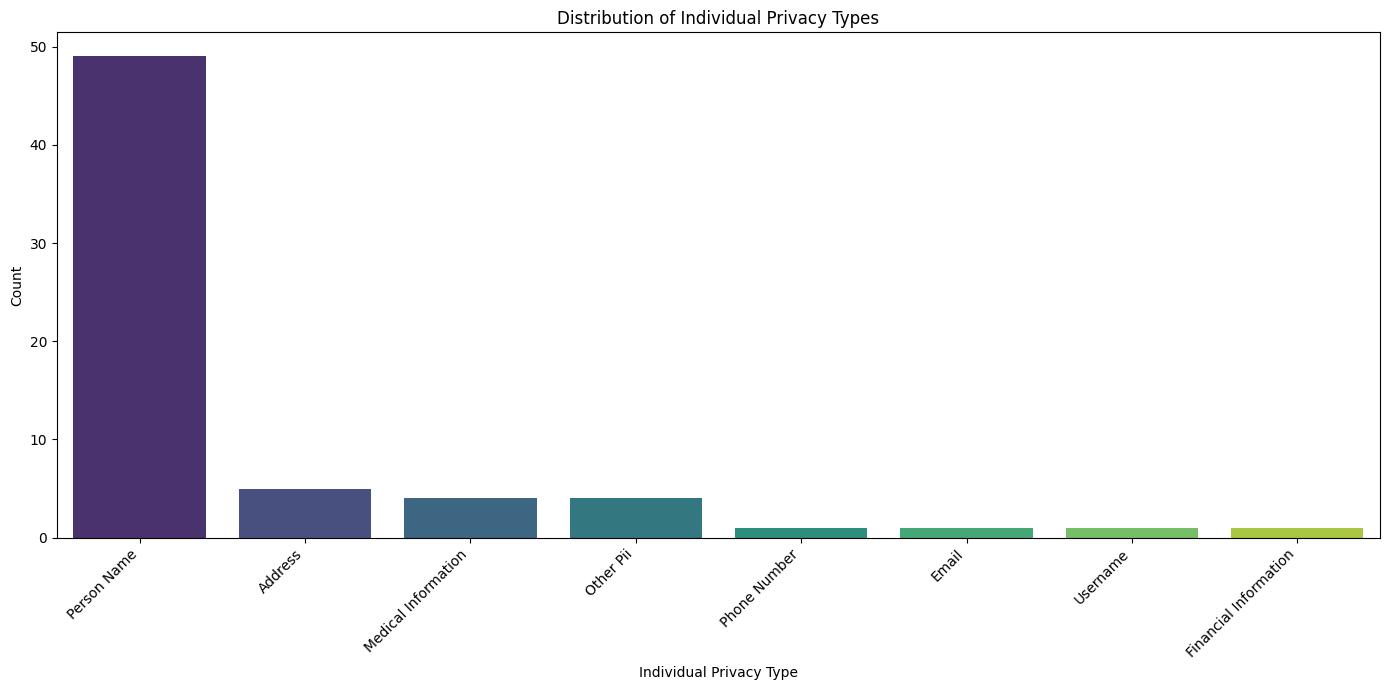

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the bar plot for individual privacy type counts
plt.figure(figsize=(14, 7))
sns.barplot(x=privacy_type_counts_exploded.index, y=privacy_type_counts_exploded.values, hue=privacy_type_counts_exploded.index, palette='viridis', legend=False)

# Add labels and title
plt.xlabel('Individual Privacy Type')
plt.ylabel('Count')
plt.title('Distribution of Individual Privacy Types')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability

# Display the plot
plt.tight_layout()
plt.show()

## Distribution of Privacy Types Across Document Categories

In [52]:
# First, re-explode the privacy_type_list to get individual privacy types for each row
exploded_privacy_types_df = merged_df.explode('privacy_type_list')

# Group by document_type and the exploded privacy_type, then count occurrences
privacy_type_by_doc_type_counts = exploded_privacy_types_df.groupby(['document_type', 'privacy_type_list']).size().unstack(fill_value=0)

print("\n--- Privacy Type Counts by Document Type ---")
display(privacy_type_by_doc_type_counts)


--- Privacy Type Counts by Document Type ---


privacy_type_list,Address,Email,Financial Information,Medical Information,Other Pii,Person Name,Phone Number,Username
document_type,,,,,,,,
<Na>,1,1,0,0,1,3,0,0
About Myself Page,0,0,0,0,1,1,0,0
Academic,0,0,0,0,0,2,0,0
Article,1,0,0,1,1,7,1,0
Blog,0,0,0,1,1,16,0,1
Forum Post,0,0,0,0,0,4,0,0
Government,2,0,0,0,0,3,0,0
News Website,0,0,0,1,0,1,0,0
Other,1,0,0,0,0,3,0,0


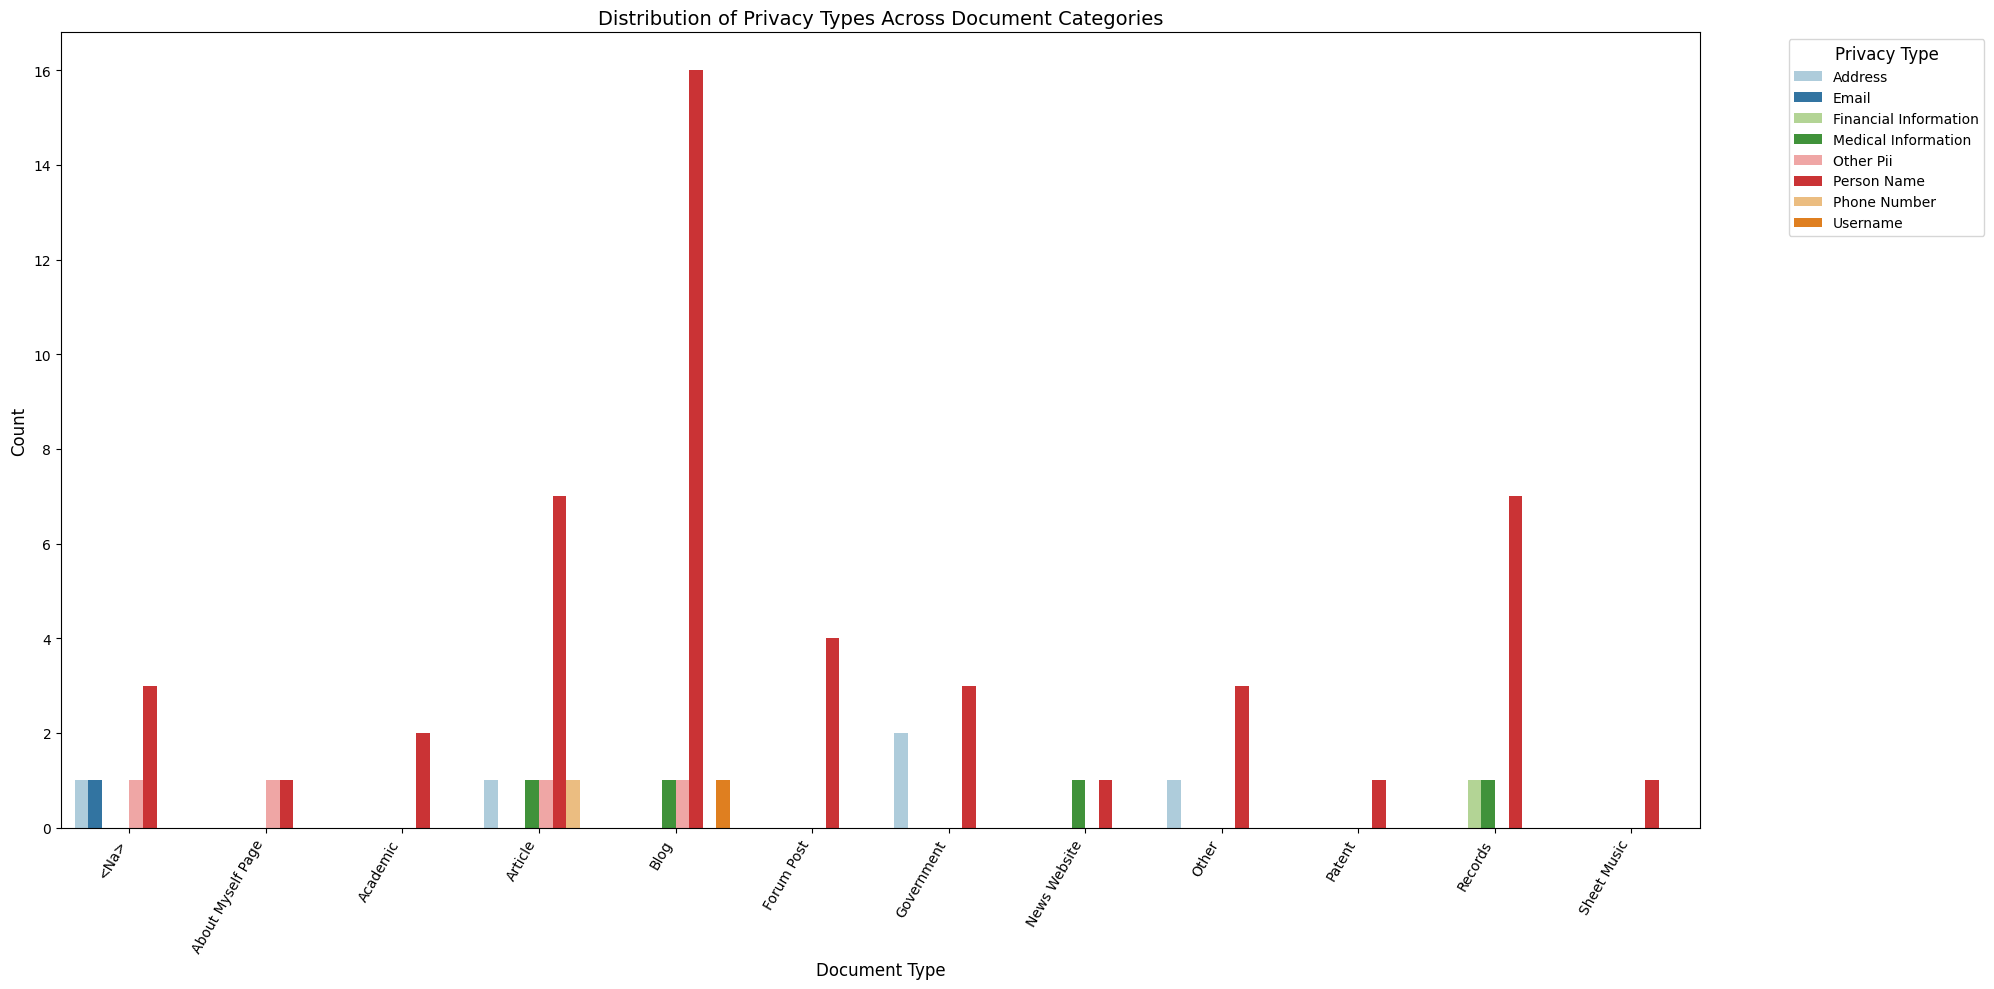

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for plotting (melt the DataFrame for easier plotting with seaborn)
plot_data = privacy_type_by_doc_type_counts.reset_index().melt(id_vars='document_type', var_name='Privacy Type', value_name='Count')

plt.figure(figsize=(20, 10)) # Increased figure size for bigger bars
sns.barplot(data=plot_data, x='document_type', y='Count', hue='Privacy Type', palette='Paired') # Changed palette for more appeal

plt.xlabel('Document Type', fontsize=12) # Increased font size for labels
plt.ylabel('Count', fontsize=12)
plt.title('Distribution of Privacy Types Across Document Categories', fontsize=14)
plt.xticks(rotation=60, ha='right', fontsize=10) # Rotated x-axis labels more for readability with larger plot
plt.yticks(fontsize=10)
plt.legend(title='Privacy Type', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, title_fontsize=12)
plt.tight_layout()
plt.show()

In [55]:
merged_df['contains_private_information'] = merged_df['privacy_type'].apply(lambda x: pd.notna(x) and x.strip() != '')

print("\n--- 'contains_private_information' Value Counts ---")
display(merged_df['contains_private_information'].value_counts())

print("\n--- Merged DataFrame Head with new column ---")
display(merged_df[['privacy_type', 'contains_private_information']].head())


--- 'contains_private_information' Value Counts ---


,count
contains_private_information,
False,77
True,51



--- Merged DataFrame Head with new column ---


,privacy_type,contains_private_information
0,<NA>,False
1,<NA>,False
2,<NA>,False
3,<NA>,False
4,<NA>,False


## Comparison of 'contains_private_information' by Document Type

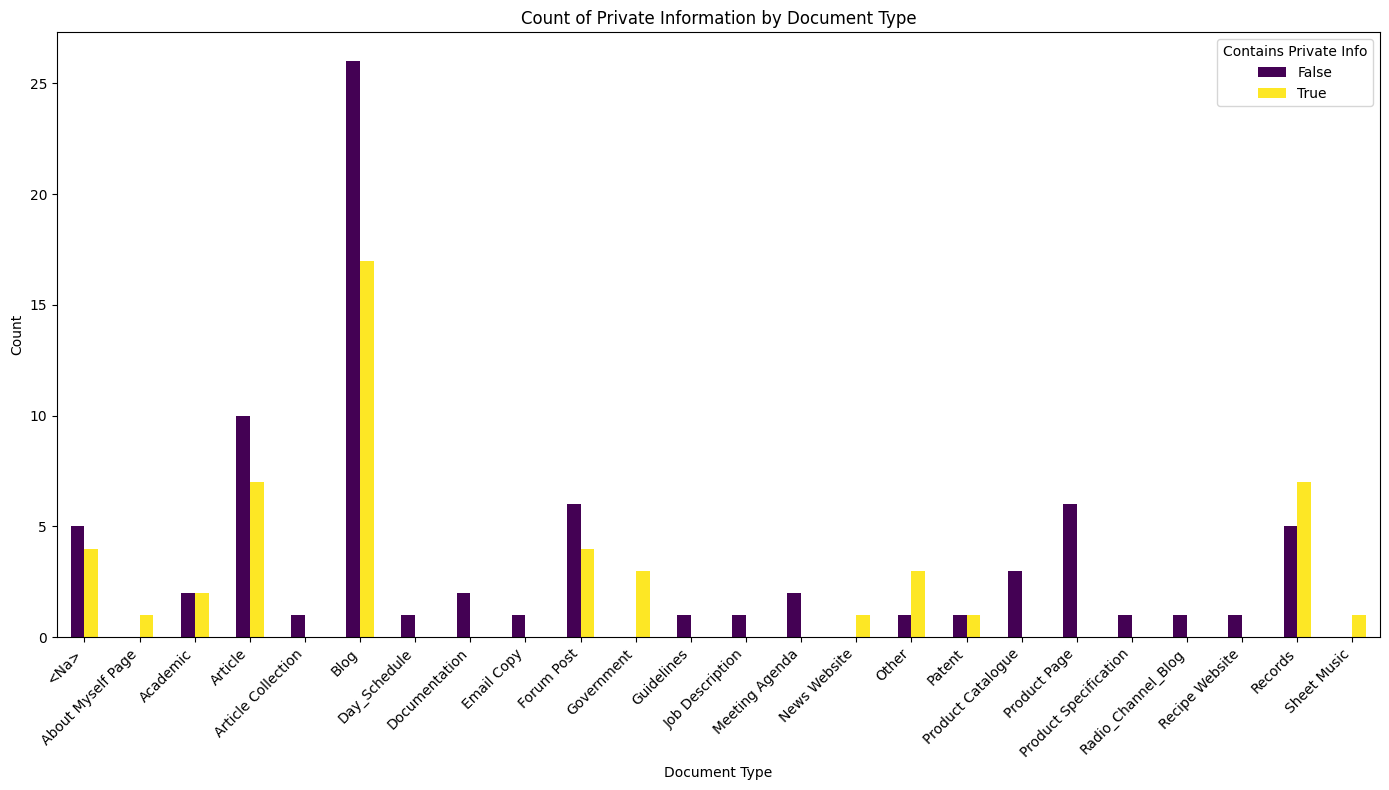

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by document_type and contains_private_information, then count
private_info_by_doc_type = merged_df.groupby(['document_type', 'contains_private_information']).size().unstack(fill_value=0)

# Plotting
fig, ax = plt.subplots(figsize=(14, 8))
private_info_by_doc_type.plot(kind='bar', ax=ax, colormap='viridis')

ax.set_title('Count of Private Information by Document Type')
ax.set_xlabel('Document Type')
ax.set_ylabel('Count')
ax.set_xticks(range(len(private_info_by_doc_type.index)))
ax.set_xticklabels(private_info_by_doc_type.index, rotation=45, ha='right')
ax.legend(title='Contains Private Info', labels=['False', 'True'])
plt.tight_layout()
plt.show()

## Comparison of 'contains_private_information' by Source

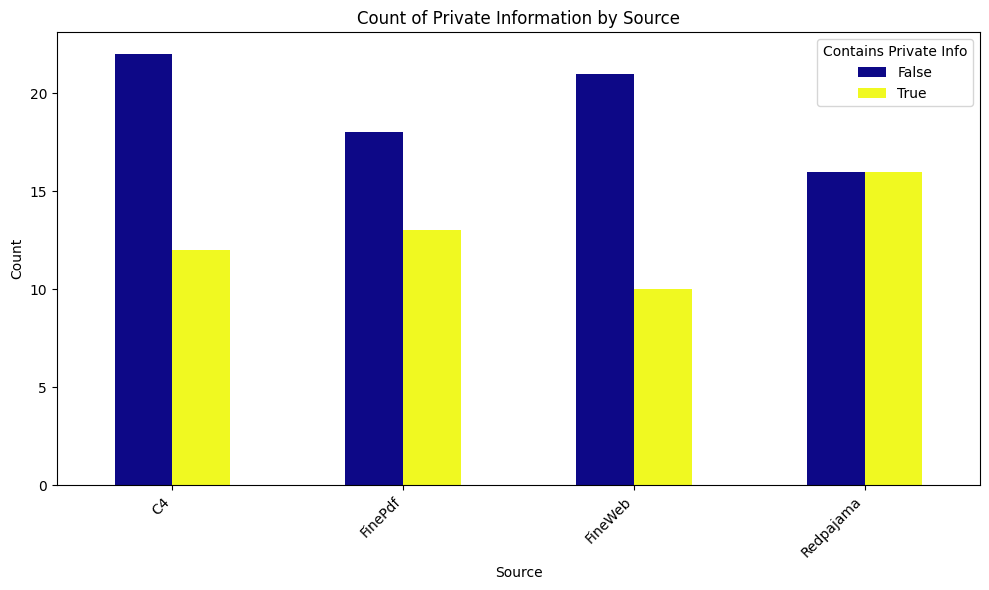

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by src and contains_private_information, then count
private_info_by_src = merged_df.groupby(['src', 'contains_private_information']).size().unstack(fill_value=0)

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))
private_info_by_src.plot(kind='bar', ax=ax, colormap='plasma')

ax.set_title('Count of Private Information by Source')
ax.set_xlabel('Source')
ax.set_ylabel('Count')
ax.set_xticks(range(len(private_info_by_src.index)))
ax.set_xticklabels(private_info_by_src.index, rotation=45, ha='right')
ax.legend(title='Contains Private Info', labels=['False', 'True'])
plt.tight_layout()
plt.show()

## Comparison of 'contains_private_information' by Topic

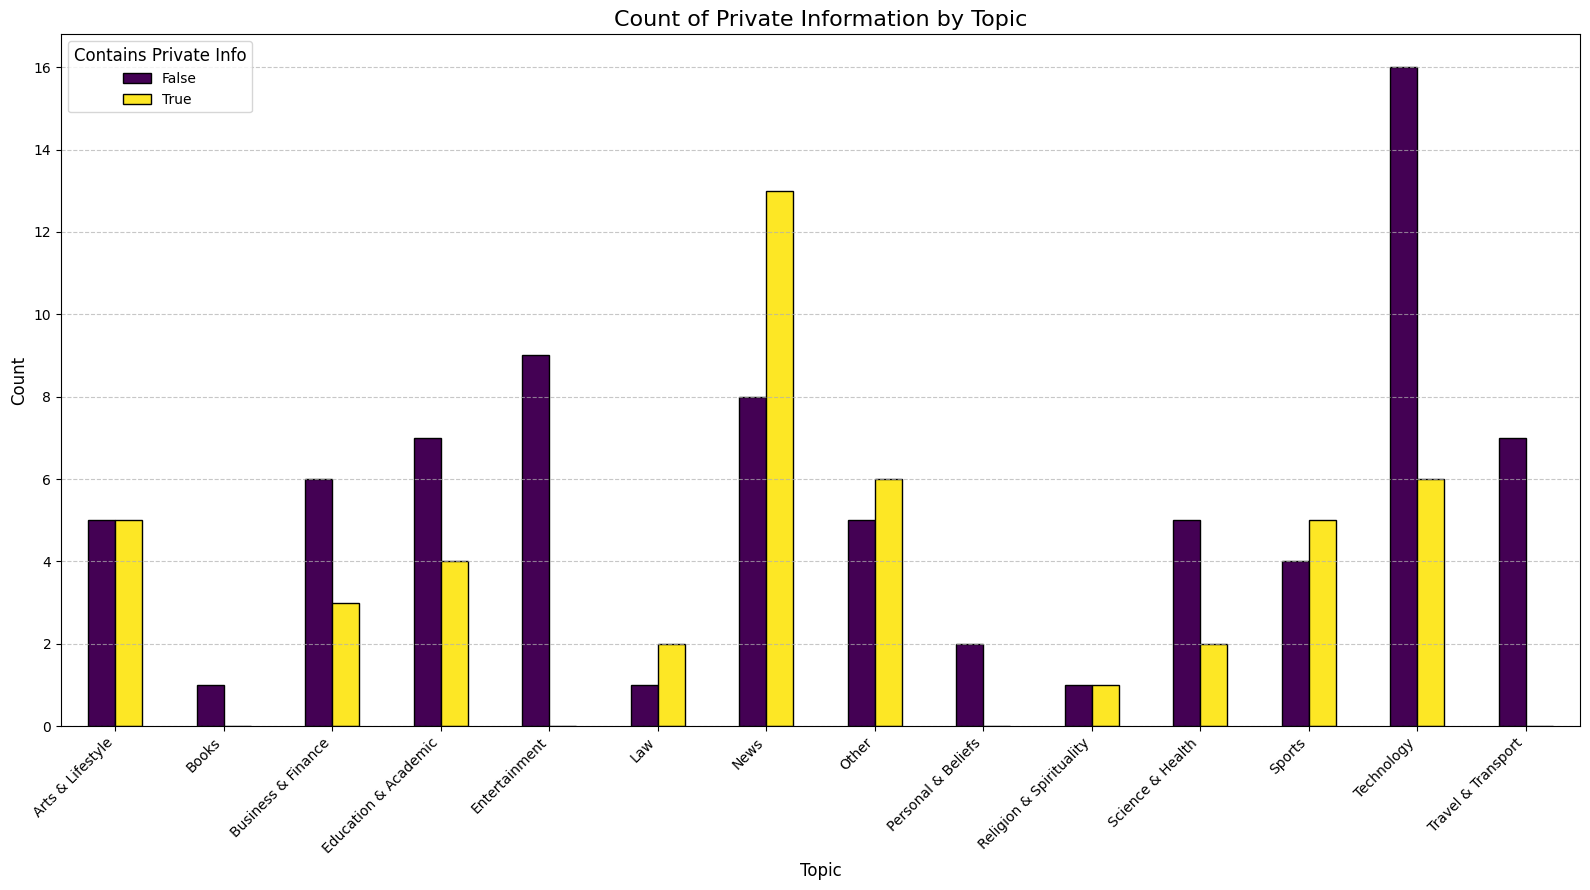

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by topic and contains_private_information, then count
private_info_by_topic = merged_df.groupby(['topic', 'contains_private_information']).size().unstack(fill_value=0)

# Plotting
fig, ax = plt.subplots(figsize=(16, 9)) # Adjust figure size for better readability
private_info_by_topic.plot(kind='bar', ax=ax, cmap='viridis', edgecolor='black') # Changed colormap and added edgecolor

ax.set_title('Count of Private Information by Topic', fontsize=16)
ax.set_xlabel('Topic', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_xticks(range(len(private_info_by_topic.index)))
ax.set_xticklabels(private_info_by_topic.index, rotation=45, ha='right', fontsize=10)
ax.legend(title='Contains Private Info', labels=['False', 'True'], fontsize=10, title_fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add grid for better comparison
plt.tight_layout()
plt.show()

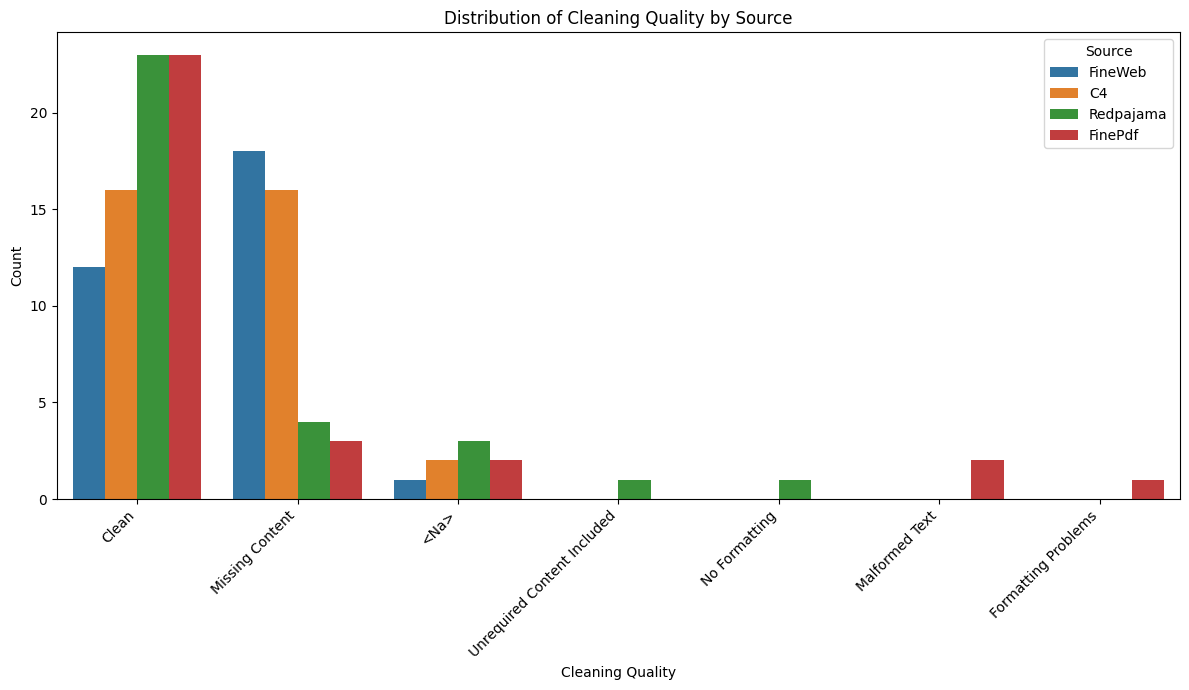

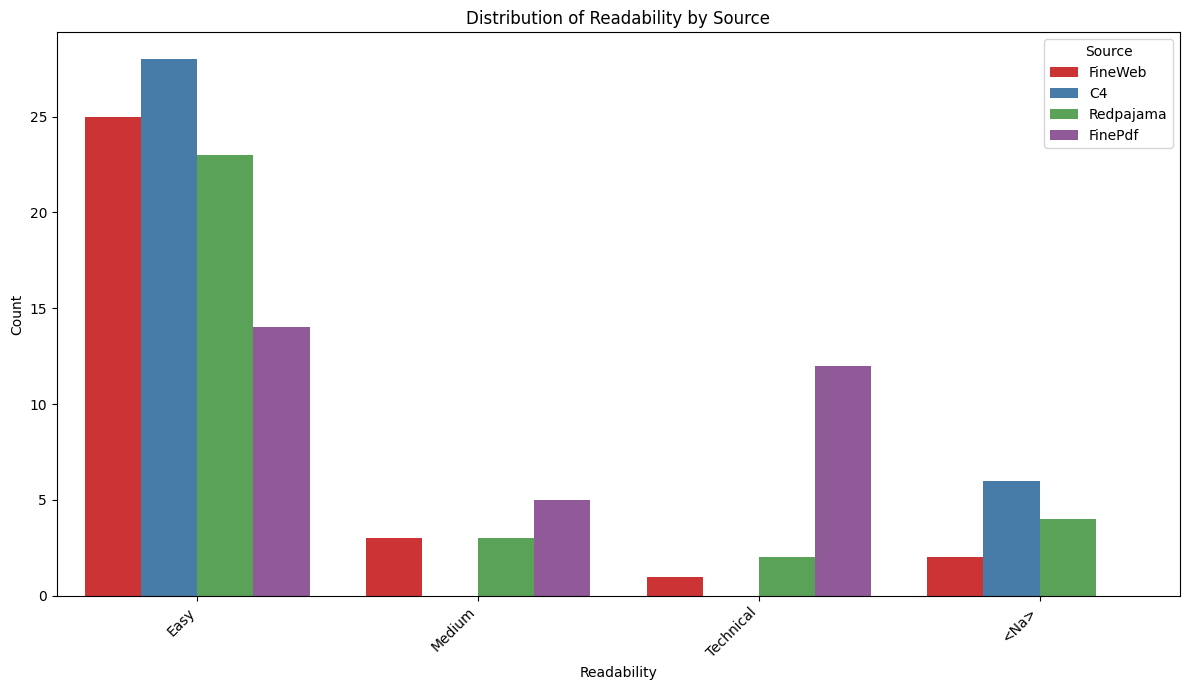

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Visualize Cleaning Quality Distribution by Source ---
plt.figure(figsize=(12, 7))
sns.countplot(data=merged_df, x='cleaning_quality', hue='src', palette='tab10') # Changed to 'tab10' for better contrast
plt.title('Distribution of Cleaning Quality by Source')
plt.xlabel('Cleaning Quality')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Source')
plt.tight_layout()
plt.show()

# --- Visualize Readability Distribution by Source ---
plt.figure(figsize=(12, 7))
sns.countplot(data=merged_df, x='readability', hue='src', palette='Set1') # Changed to 'Set1' for better contrast
plt.title('Distribution of Readability by Source')
plt.xlabel('Readability')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Source')
plt.tight_layout()
plt.show()


--- Average Quality Score by Source ---


,quality_score
src,
Redpajama,8.843750
FinePdf,8.774194
C4,8.647059
FineWeb,7.419355


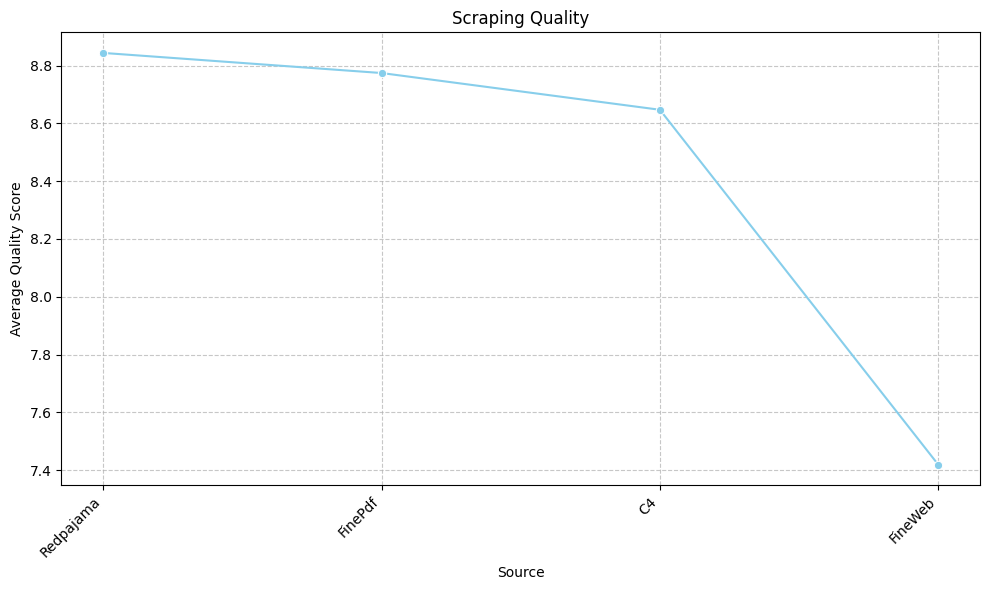

In [107]:
print("\n--- Average Quality Score by Source ---")
average_quality_by_src = merged_df.groupby('src')['quality_score'].mean().sort_values(ascending=False)
display(average_quality_by_src)

# Visualize the average quality score by source using a line plot
plt.figure(figsize=(10, 6))
sns.lineplot(x=average_quality_by_src.index, y=average_quality_by_src.values, marker='o', color='skyblue')
plt.title('Scraping Quality')
plt.xlabel('Source')
plt.ylabel('Average Quality Score')
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [71]:
# Display 2 random samples for False Positives (model predicts PII, manual tag is none)
print("--- Samples: Model False Positives (Model PII, Manual None) ---")
fp_samples_all = merged_df[(merged_df['is_fp'] == True) & (merged_df['privacy_type'].isna())]
if not fp_samples_all.empty:
    # Ensure we don't try to sample more than available rows
    num_samples_fp = min(2, len(fp_samples_all))
    fp_samples_random = fp_samples_all.sample(n=num_samples_fp, random_state=42) # Use random_state for reproducibility
    display(fp_samples_random[['text', 'privacy_type', 'standardized_predicted_entities', 'is_fp', 'is_fn']])
else:
    print("No False Positive samples found where privacy_type is None.")

print("\n--- Samples: Model False Negatives (Manual PII, Model None) ---")
# Display 2 random samples for False Negatives (manual tag PII, model predicts none)
fn_samples_all = merged_df[(merged_df['is_fn'] == True) & (merged_df['standardized_predicted_entities'].isna())]
if not fn_samples_all.empty:
    # Ensure we don't try to sample more than available rows
    num_samples_fn = min(2, len(fn_samples_all))
    fn_samples_random = fn_samples_all.sample(n=num_samples_fn, random_state=42) # Use random_state for reproducibility
    display(fn_samples_random[['text', 'privacy_type', 'standardized_predicted_entities', 'is_fp', 'is_fn']])
else:
    print("No False Negative samples found where standardized_predicted_entities is None.")

--- Samples: Model False Positives (Model PII, Manual None) ---


,text,privacy_type,standardized_predicted_entities,is_fp,is_fn
49,I have existing web site brittlloyd.org. I ope...,<NA>,URL,True,False
88,Y Konnenktoren-unsteril-Verpackungseinheit: 10...,<NA>,Account Number,True,False



--- Samples: Model False Negatives (Manual PII, Model None) ---


,text,privacy_type,standardized_predicted_entities,is_fp,is_fn
104,Florida Rag\n\nCharacteristic\n\nGeo.L.Lowry (...,Person Name,<NA>,False,True
96,529\n\n＊\n\n社會正義、差異政治、以及溝通民主\n\n郭秋永\n\n中央研究院人文...,Person Name,<NA>,False,True


In [80]:
print(fp_samples_all.iloc[2]['text'])

"Good Morning America" and Parade magazine unveiled their lists of must-read books for the summer. From thrillers to biographies to light reading, these stories are un-put-downable.
If you're in search of that perfect page-turner for your summer vacation, look no further!
CLICK HERE for more hot summer book picks from Parade magazine.
CLICK HERE for our special books page full of book excerpts, author interviews and more!
Jack Reacher's latest adventure begins when he suspects a female suicide bomber is aboard a Manhattan subway car. Her death leads him on a path back to the war in Afghanistan against the Soviets in the 1980s.
After he's laid off in the latest budget cuts at The Los Angeles Times, reporter Jack McEvoy plans to write the murder story of his career in his last two weeks at the newspaper.
When Sandra Jones, a hardworking young wife and mother, disappears without a trace one day, Sgt. Det. D.D. Warren is called in on the case. As he's digging, he discovers that her family 

In [98]:
print(fp_samples_all.iloc[2]['privacy_type'])

<NA>


In [81]:
fp_samples_all.iloc[2]['model_privacy_predictions']

[{'entity': 'B-private_person',
  'score': np.float32(0.54670537),
  'index': 259,
  'word': 'ĠPaul',
  'start': 1246,
  'end': 1251},
 {'entity': 'I-private_person',
  'score': np.float32(0.7430308),
  'index': 260,
  'word': 'ĠMad',
  'start': 1251,
  'end': 1255},
 {'entity': 'I-private_person',
  'score': np.float32(0.5924892),
  'index': 261,
  'word': 'ri',
  'start': 1255,
  'end': 1257},
 {'entity': 'B-private_person',
  'score': np.float32(0.9704735),
  'index': 264,
  'word': 'ĠKat',
  'start': 1271,
  'end': 1275},
 {'entity': 'I-private_person',
  'score': np.float32(0.9522806),
  'index': 265,
  'word': 'ia',
  'start': 1275,
  'end': 1277},
 {'entity': 'I-private_person',
  'score': np.float32(0.94312835),
  'index': 266,
  'word': 'ĠSol',
  'start': 1277,
  'end': 1281},
 {'entity': 'E-private_person',
  'score': np.float32(0.9625708),
  'index': 267,
  'word': 'az',
  'start': 1281,
  'end': 1283}]

In [86]:
print(fp_samples_all.iloc[5]['text'])

Route: (40I-) MGY-I19-MGY
Weather: Overcast, 28 degrees, wind 200 degrees at 6 knots
With 269 landings, five months of training, nearly 75 flight hours, plenty of frustration, tons of fun, at least $6000 spent, and so many great memories behind me... I'm a Private Pilot! The weather cooperated and I went up with the examiner to complete the flying portion of my checkride, following last weekend's oral exam. Everything went well and I didn't feel any nerves aside from a little hope that I wouldn't make any boneheaded mistakes. Luckily, I did not. I am now the proud holder of a Temporary Airman Certificate, good until my plastic FAA certificate arrives in the mail.
As I did with the oral exam, I'll share the details of the checkride below. And make sure you read the end of the post, as I got to deal with some serious craziness when I went to leave Wright Brothers.
- I arrived at Stewart early in order to get a weather briefing, compute my weight and balance, and make sure I had all the p

In [87]:
fp_samples_all.iloc[5]['model_privacy_predictions']

[{'entity': 'S-private_person',
  'score': np.float32(0.9999491),
  'index': 1677,
  'word': 'ĠJoe',
  'start': 7284,
  'end': 7288},
 {'entity': 'S-private_person',
  'score': np.float32(0.99983406),
  'index': 1679,
  'word': 'ĠDave',
  'start': 7291,
  'end': 7296},
 {'entity': 'B-account_number',
  'score': np.float32(0.72741467),
  'index': 2128,
  'word': '603',
  'start': 9314,
  'end': 9317},
 {'entity': 'E-account_number',
  'score': np.float32(0.8322775),
  'index': 2129,
  'word': '38',
  'start': 9317,
  'end': 9319},
 {'entity': 'S-private_person',
  'score': np.float32(0.9999831),
  'index': 2501,
  'word': 'ĠStewart',
  'start': 10931,
  'end': 10939},
 {'entity': 'S-private_person',
  'score': np.float32(0.9999535),
  'index': 2514,
  'word': 'ĠDave',
  'start': 10990,
  'end': 10995}]

In [102]:
print(fn_samples_all.iloc[10]['text'])

HKJCC Hong Kong Inter-School Championships 2015 - Lower Primary Division

Final ranking

| Rank | Team | Gam. | + | = | - | MP |
|---|---|---|---|---|---|---|
| 1 | 107 Pui Ching Primary School | 7 | 5 | 1 | 1 | 11 |
| 2 | 113 Hong Kong International School B | 7 | 5 | 0 | 2 | 10 |
| 3 | 108 Singapore International School A | 7 | 4 | 2 | 1 | 10 |
| 4 | 111 German Swiss Int'l School B | 7 | 4 | 2 | 1 | 10 |
| 5 | 109 Discovery College | 7 | 3 | 4 | 0 | 10 |
| 6 | 105 Hong Kong International School A | 7 | 5 | 0 | 2 | 10 |
| 7 | 103 German Swiss Int'l School A | 7 | 3 | 3 | 1 | 9 |
| 8 | 102 Chan's Creative School A | 7 | 4 | 0 | 3 | 8 |
| 9 | 114 Singapore International School B | 7 | 4 | 0 | 3 | 8 |
| 10 | 121 Hong Kong International School E | 7 | 3 | 1 | 3 | 7 |
| 11 | 104 Glenealy School A | 7 | 2 | 3 | 2 | 7 |
| 12 | 110 Chan's Creative School B | 7 | 3 | 1 | 3 | 7 |
| 13 | 118 Singapore International School C | 7 | 3 | 0 | 4 | 6 |
| 14 | 115 German Swiss Int'l School C | 7 | 2 | 2

In [103]:
print(fn_samples_all.iloc[10]['model_privacy_predictions'])

<NA>


In [104]:
print(fn_samples_all.iloc[10]['privacy_type'])

Person Name


In [96]:
print(fn_samples_all.iloc[5]['text'])

Two kinds of pseudonymity
Consider two examples of pseudonymity:
Samuel Clemens writes Life on the Mississippi, signing it “Mark Twain”.
Konrad Kujau writes The Hitler Diaries, signing them “Adolf Hitler”.
There is a crucial literary difference here: tokens of “Mark Twain” in Life on the Mississippi (say, on the title page) refer to Samuel Clemens, while any tokens of “Adolf Hitler” in The Hitler Diaries would refer to Adolf Hitler. We can correctly say that Mark Twain is Samuel Clemens and wrote Life on the Mississippi, but we cannot say that Adolf Hitler is Konrad Kujau or that Adolf Hitler wrote The Hitler Diaries. On the other hand, when Clemens’ text speaks in the first person about life on the Mississippi, the text tells us about Clemens’ life. But when Kujau’s text speaks in the first person about life in Berlin, the text tells us about Hitler’s life.
In fact, strictly speaking a pen name like “Samuel Clemens” is not pseudonymous in the etymological sense of the word—“falsely na

In [97]:
print(fn_samples_all.iloc[5]['model_privacy_predictions'])

<NA>
